In [1]:
import os
import urllib.request
import zipfile
import io
import pandas as pd
import glob

# Define public replica URLs for the 2019 dataset splits
url_a = "https://raw.githubusercontent.com/Abhi5hekk/EarlySepsisPrediction/master/training_setA.zip"
url_b = "https://raw.githubusercontent.com/Abhi5hekk/EarlySepsisPrediction/master/training_setB.zip"

def download_and_extract_data(url, output_folder):
    print(f"Downloading data from: {url}")
    request_headers = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(request_headers) as response:
        with zipfile.ZipFile(io.BytesIO(response.read())) as zip_file:
            zip_file.extractall(output_folder)
    print(f"Successfully extracted files to: {output_folder}")

# Execute download and extraction for both patient cohorts
download_and_extract_data(url_a, "set_a")
download_and_extract_data(url_b, "set_b")

Successfully extracted files to: set_a
Successfully extracted files to: set_b


In [2]:
def merge_patient_records(base_directory, record_limit=2000):
    search_path = os.path.join(base_directory, '**', '*.psv')
    discovered_files = glob.glob(search_path, recursive=True)
    print(f"Discovered {len(discovered_files)} records in {base_directory}. Processing safe baseline sample of {record_limit}...")

    compiled_frames = []
    for file_path in discovered_files[:record_limit]:
        patient_identifier = os.path.basename(file_path).replace('.psv', '')
        individual_df = pd.read_csv(file_path, sep='|')
        individual_df['Patient_ID'] = patient_identifier
        individual_df['ICU_Hour_Step'] = range(len(individual_df))
        compiled_frames.append(individual_df)

    return pd.concat(compiled_frames, ignore_index=True)

print("Compiling Cohort A...")
df_cohort_a = merge_patient_records("set_a")

print("\nCompiling Cohort B...")
df_cohort_b = merge_patient_records("set_b")

# Combine both cohorts into a master dataframe
master_df = pd.concat([df_cohort_a, df_cohort_b], ignore_index=True)
print(f"\nMatrix assembly complete. Master DataFrame Shape: {master_df.shape}")

Compiling Cohort A...
Discovered 20336 records in set_a. Processing safe baseline sample of 2000...

Compiling Cohort B...
Discovered 20000 records in set_b. Processing safe baseline sample of 2000...

Matrix assembly complete. Master DataFrame Shape: (154582, 43)


In [3]:
# Create a dedicated copy for transformation steps
working_df = master_df.copy()

# 1. Forward-fill missing values per unique patient, then apply global fallback
clinical_features = [col for col in working_df.columns if col not in ['Patient_ID', 'SepsisLabel', 'ICU_Hour_Step']]
working_df[clinical_features] = working_df.groupby('Patient_ID')[clinical_features].ffill()
working_df[clinical_features] = working_df[clinical_features].fillna(working_df[clinical_features].median())

# 2. Build the 6-Hour Lookback Window Window target logic
working_df['Prediction_Target'] = 0

def enforce_temporal_window(group):
    positive_indices = group.index[group['SepsisLabel'] == 1]

    if len(positive_indices) > 0:
        first_onset_index = positive_indices[0]
        all_group_indices = group.index
        relative_position = list(all_group_indices).index(first_onset_index)

        # Determine target window 6 hours prior to clinical determination
        window_start_position = max(0, relative_position - 6)
        target_indices = all_group_indices[window_start_position:relative_position]

        group.loc[target_indices, 'Prediction_Target'] = 1

        # Discard all tracking records post-diagnosis to eliminate temporal leakage
        retained_indices = all_group_indices[:relative_position]
        return group.loc[retained_indices]

    return group

print("Enforcing 6-hour lookback constraints and isolating historical trajectories...")
cleansed_df = working_df.groupby('Patient_ID', group_keys=False).apply(lambda x: enforce_temporal_window(x))

print(f"Original Row Count: {working_df.shape[0]}")
print(f"Cleaned Row Count Post-Leakage Separation: {cleansed_df.shape[0]}")
print("\nTarget Label Breakdown:\n", cleansed_df['Prediction_Target'].value_counts())


Enforcing 6-hour lookback constraints and isolating historical trajectories...
Original Row Count: 154582
Cleaned Row Count Post-Leakage Separation: 151797

Target Label Breakdown:
 Prediction_Target
0    150396
1      1401
Name: count, dtype: int64


/tmp/ipykernel_10082/571761163.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cleansed_df = working_df.groupby('Patient_ID', group_keys=False).apply(lambda x: enforce_temporal_window(x))


Training Machine Learning Model Pipeline...

--- Model Classification Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29538
           1       0.04      0.05      0.05       273

    accuracy                           0.98     29811
   macro avg       0.52      0.52      0.52     29811
weighted avg       0.98      0.98      0.98     29811



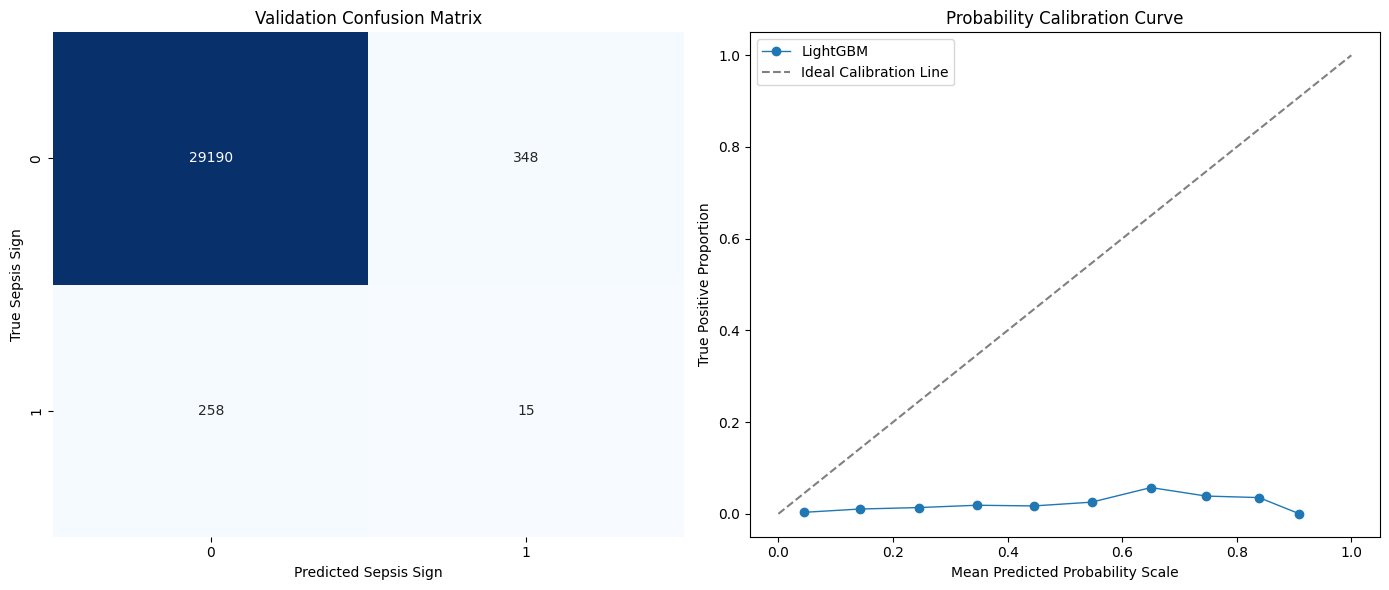


Brier Score Loss: 0.05560


In [4]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Split data by patient ID to prevent identity cross-contamination
unique_ids = cleansed_df['Patient_ID'].unique()
patient_max_labels = cleansed_df.groupby('Patient_ID')['Prediction_Target'].max()

train_ids, validation_ids = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=42,
    stratify=patient_max_labels
)

train_matrix = cleansed_df[cleansed_df['Patient_ID'].isin(train_ids)]
validation_matrix = cleansed_df[cleansed_df['Patient_ID'].isin(validation_ids)]

# Isolate feature inputs from metadata structures
model_features = [col for col in cleansed_df.columns if col not in ['Patient_ID', 'SepsisLabel', 'Prediction_Target', 'ICU_Hour_Step']]
X_train, y_train = train_matrix[model_features], train_matrix['Prediction_Target']
X_val, y_val = validation_matrix[model_features], validation_matrix['Prediction_Target']

# 2. Configure LightGBM with loss adjustment for severe class imbalance
imbalance_adjustment_factor = (len(y_train) - sum(y_train)) / sum(y_train)

lgb_classifier = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    scale_pos_weight=imbalance_adjustment_factor,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

print("Training Machine Learning Model Pipeline...")
lgb_classifier.fit(X_train, y_train)

# 3. Predict probabilities and tune the positive threshold criteria
predicted_probabilities = lgb_classifier.predict_proba(X_val)[:, 1]
decision_threshold = 0.75
class_predictions = (predicted_probabilities >= decision_threshold).astype(int)

print("\n--- Model Classification Performance ---")
print(classification_report(y_val, class_predictions))

# 4. Generate and Save Performance Visualizations (Fixed plotting execution)
fig = plt.figure(figsize=(14, 6))

# Plot Confusion Matrix
plt.subplot(1, 2, 1)
computed_cm = confusion_matrix(y_val, class_predictions)
sns.heatmap(computed_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Sepsis Sign")
plt.ylabel("True Sepsis Sign")

# Plot Calibration Curve
plt.subplot(1, 2, 2)
empirical_true, model_predicted = calibration_curve(y_val, predicted_probabilities, n_bins=10)
plt.plot(model_predicted, empirical_true, marker='o', linewidth=1, label='LightGBM')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal Calibration Line')
plt.title("Probability Calibration Curve")
plt.xlabel("Mean Predicted Probability Scale")
plt.ylabel("True Positive Proportion")
plt.legend()

plt.tight_layout()
plt.savefig("evaluation_results.png")
plt.show()

print(f"\nBrier Score Loss: {brier_score_loss(y_val, predicted_probabilities):.5f}")